# Interpretação de filtros de derivada — Exercício 10

Seja $f$ um sinal discreto, amostrado a cada $\Delta t$. Se

$$
p = \frac{1}{2\Delta t}[1, 0, -1] \qquad q = \frac{1}{\Delta t^2}[1, -2, 1]
$$

Interprete o significado de $g = f * p$ e $h = f * q$.

Ver código original em [convolucao2.py](./convolucao2.py).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Sinal de exemplo

Vamos usar uma wavelet Ricker como sinal $f$ de teste, por ser um sinal suave e comum em processamento sísmico, o que facilita interpretar visualmente o efeito dos filtros $p$ e $q$.

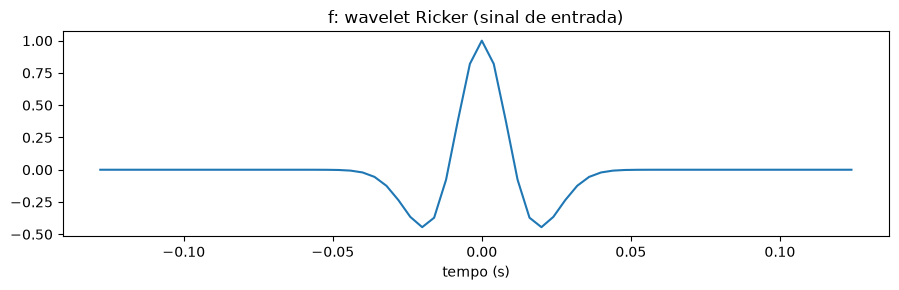

In [2]:
delta_t = 0.004  # 4 ms, valor comum de dt em dados sísmicos
fpeak = 20  # Hz

t = np.arange(-0.128, 0.128, delta_t)

def ricker(t, fpeak):
    a = (np.pi * fpeak * t) ** 2
    return (1 - 2*a) * np.exp(-a)

f = ricker(t, fpeak)

plt.figure(figsize=(9, 3))
plt.plot(t, f)
plt.title("f: wavelet Ricker (sinal de entrada)")
plt.xlabel("tempo (s)")
plt.tight_layout()
plt.show()

In [3]:
p = (1 / (2 * delta_t)) * np.array([1, 0, -1])
q = (1 / delta_t**2) * np.array([1, -2, 1])

g = np.convolve(f, p, mode="same")
h = np.convolve(f, q, mode="same")

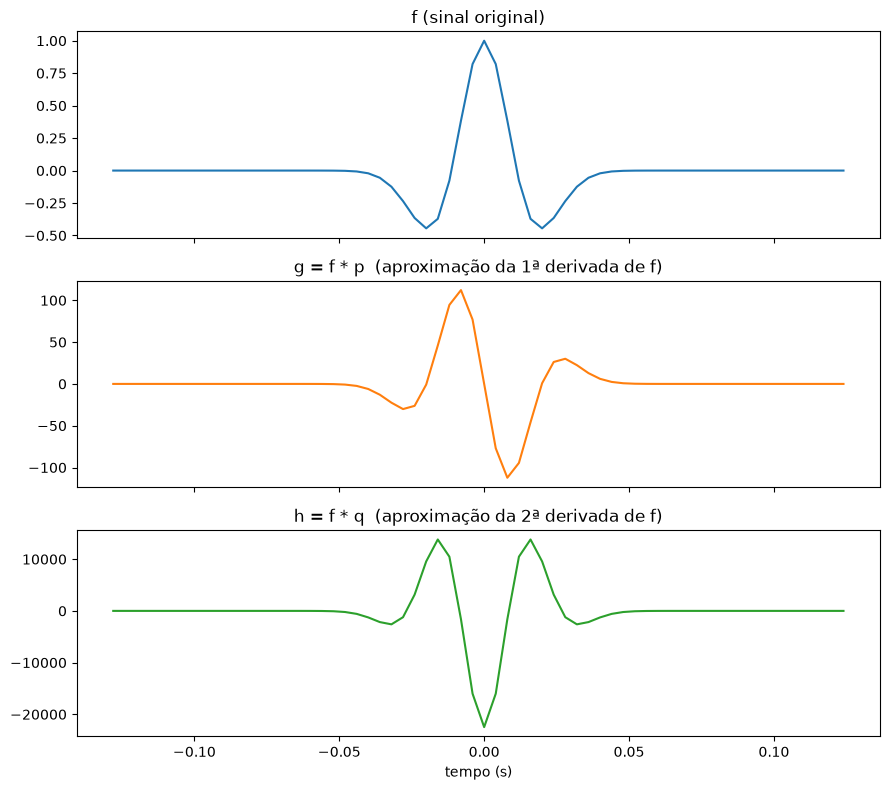

In [4]:
fig, axs = plt.subplots(3, 1, figsize=(9, 8), sharex=True)

axs[0].plot(t, f, color="tab:blue")
axs[0].set_title("f (sinal original)")

axs[1].plot(t, g, color="tab:orange")
axs[1].set_title("g = f * p  (aproximação da 1ª derivada de f)")

axs[2].plot(t, h, color="tab:green")
axs[2].set_title("h = f * q  (aproximação da 2ª derivada de f)")
axs[2].set_xlabel("tempo (s)")

plt.tight_layout()
plt.show()

## Interpretação

- $p = \frac{1}{2\Delta t}[1, 0, -1]$ é o operador de diferença central, uma aproximação discreta da **primeira derivada**. Por isso $g = f * p \approx f'$: $g$ cruza zero onde $f$ tem máximos/mínimos locais e tem maior amplitude nos trechos de maior inclinação de $f$.

- $q = \frac{1}{\Delta t^2}[1, -2, 1]$ é o operador de segunda diferença, uma aproximação discreta da **segunda derivada**. Por isso $h = f * q \approx f''$: $h$ é negativo onde $f$ é côncavo para baixo (perto do pico da wavelet) e positivo onde $f$ é côncavo para cima (nos lóbulos laterais), cruzando zero nos pontos de inflexão de $f$.

- Em termos sísmicos, aplicar $p$ realça mudanças de amplitude (bordas/transições do sinal), enquanto aplicar $q$ realça a curvatura do sinal e tende a amplificar ruído de alta frequência, já que a segunda derivada acentua ainda mais as componentes de alta frequência.